<a href="https://colab.research.google.com/github/mritu2000-bit/vehicle-detection-satellite-imagery/blob/main/object_detection_DOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Check files
files = os.listdir('/content')
print(files)

['.config', '.ipynb_checkpoints', 'Dataset', 'sample_data']


In [ ]:
print(os.listdir('/content/Dataset'))

['P0003.txt', 'P0003.png']


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
from PIL import Image

In [ ]:
# Image Loading
img = Image.open('/content/Dataset/P0003.png')
img_array = np.array(img)

print("Image size:", img.size)
print("Image shape:", img_array.shape)

Image size: (1147, 1023)
Image shape: (1023, 1147, 3)


In [ ]:
# Annotations Loading
annotations = []
with open('/content/Dataset/P0003.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 9:
            coords = list(map(float, parts[:8]))
            category = parts[8]
            difficult = int(parts[9]) if len(parts) > 9 else 0
            annotations.append({
                'coords': coords,
                'category': category,
                'difficult': difficult
            })

print(f"Total annotations: {len(annotations)}")

Total annotations: 55


In [ ]:
# Count by category
categories = {}
for ann in annotations:
    cat = ann['category']
    categories[cat] = categories.get(cat, 0) + 1

print("Objects by category:")
for cat, count in categories.items():
    print(f"  {cat}: {count}")

Objects by category:
  small-vehicle: 15
  large-vehicle: 40


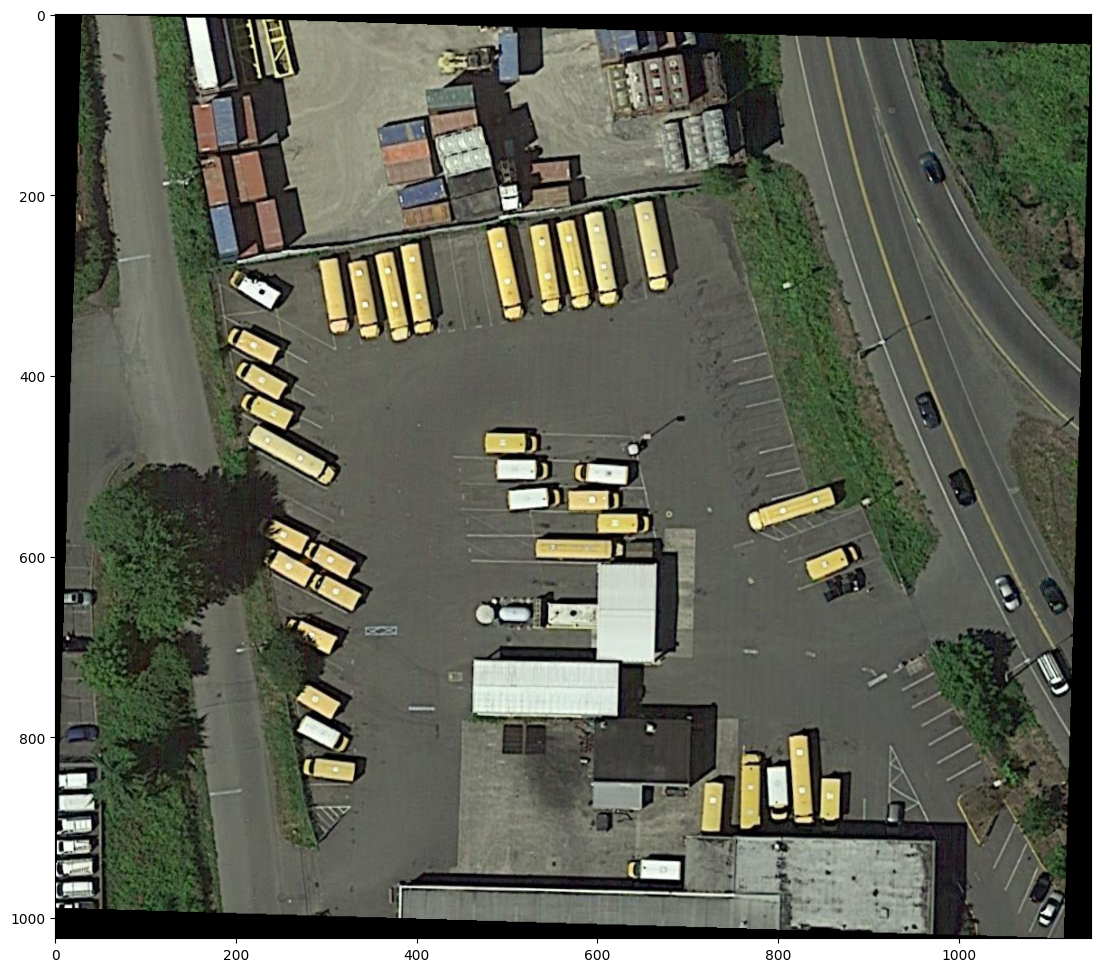

In [ ]:
# Visualization of ground truth
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
ax.imshow(img_array)

colors = {'small-vehicle': 'red', 'large-vehicle': 'blue'}

for ann in annotations:
    coords = ann['coords']
    category = ann['category']
    difficult = ann['difficult']

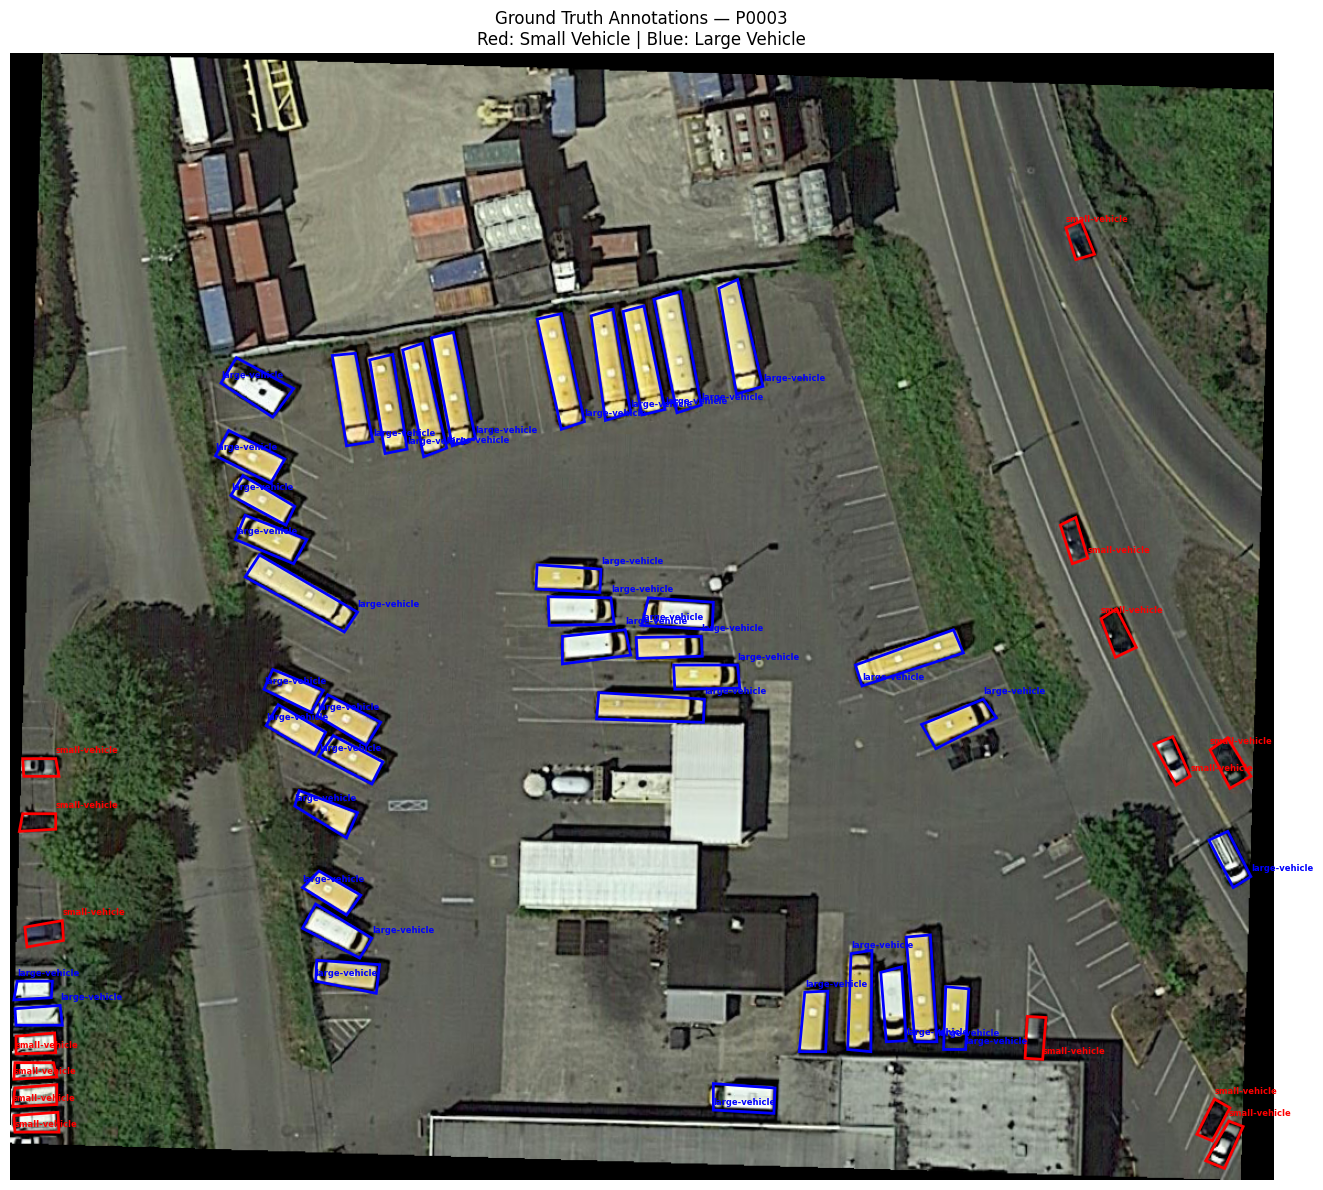

Ground truth visualization saved.


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
ax.imshow(img_array)

colors = {'small-vehicle': 'red', 'large-vehicle': 'blue'}

for ann in annotations:
    coords = ann['coords']
    category = ann['category']
    difficult = ann['difficult']

    pts = np.array([[coords[0], coords[1]],
                    [coords[2], coords[3]],
                    [coords[4], coords[5]],
                    [coords[6], coords[7]]])

    color = colors.get(category, 'green')
    polygon = Polygon(pts, closed=True, edgecolor=color, facecolor='none', linewidth=2)
    ax.add_patch(polygon)
    ax.text(coords[0], coords[1]-5, category, color=color, fontsize=6, fontweight='bold')

ax.set_title('Ground Truth Annotations — P0003\nRed: Small Vehicle | Blue: Large Vehicle')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/Dataset/ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ground truth visualization saved.")

In [ ]:
import cv2

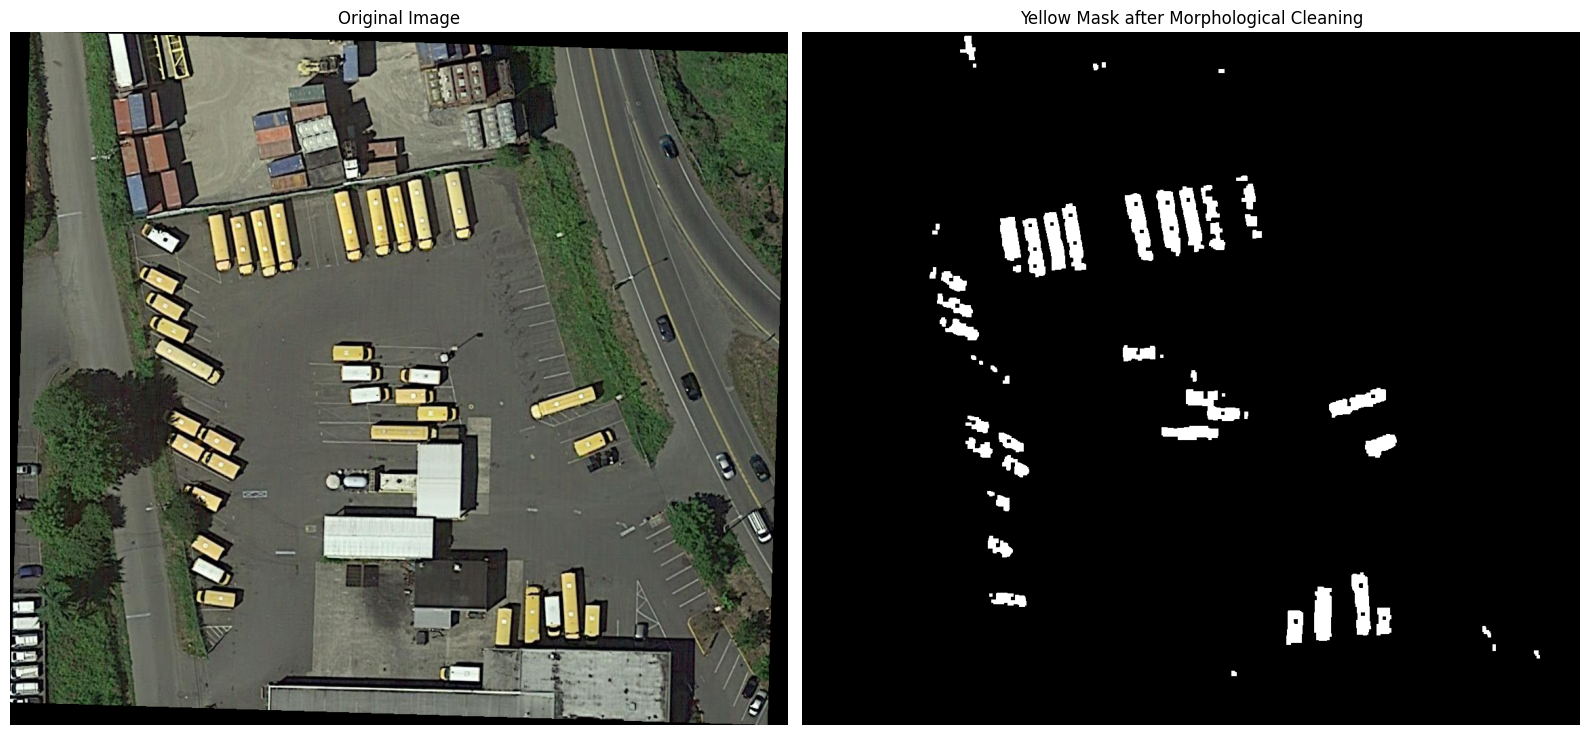

Mask saved.


In [ ]:
# Loading of image
img_bgr = cv2.imread('/content/Dataset/P0003.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Step 1 - Defining yellow color range in HSV
yellow_lower = np.array([20, 80, 80])
yellow_upper = np.array([35, 255, 255])

# Step 2 - Creating yellow mask
yellow_mask = cv2.inRange(img_hsv, yellow_lower, yellow_upper)

# Step 3 - Morphological operations to clean noise
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

# Step 4 - Visualization of mask
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mask_clean, cmap='gray')
axes[1].set_title('Yellow Mask after Morphological Cleaning')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/Dataset/yellow_mask.png', dpi=150)
plt.show()
print("Mask saved.")

Total detections after size filtering: 30


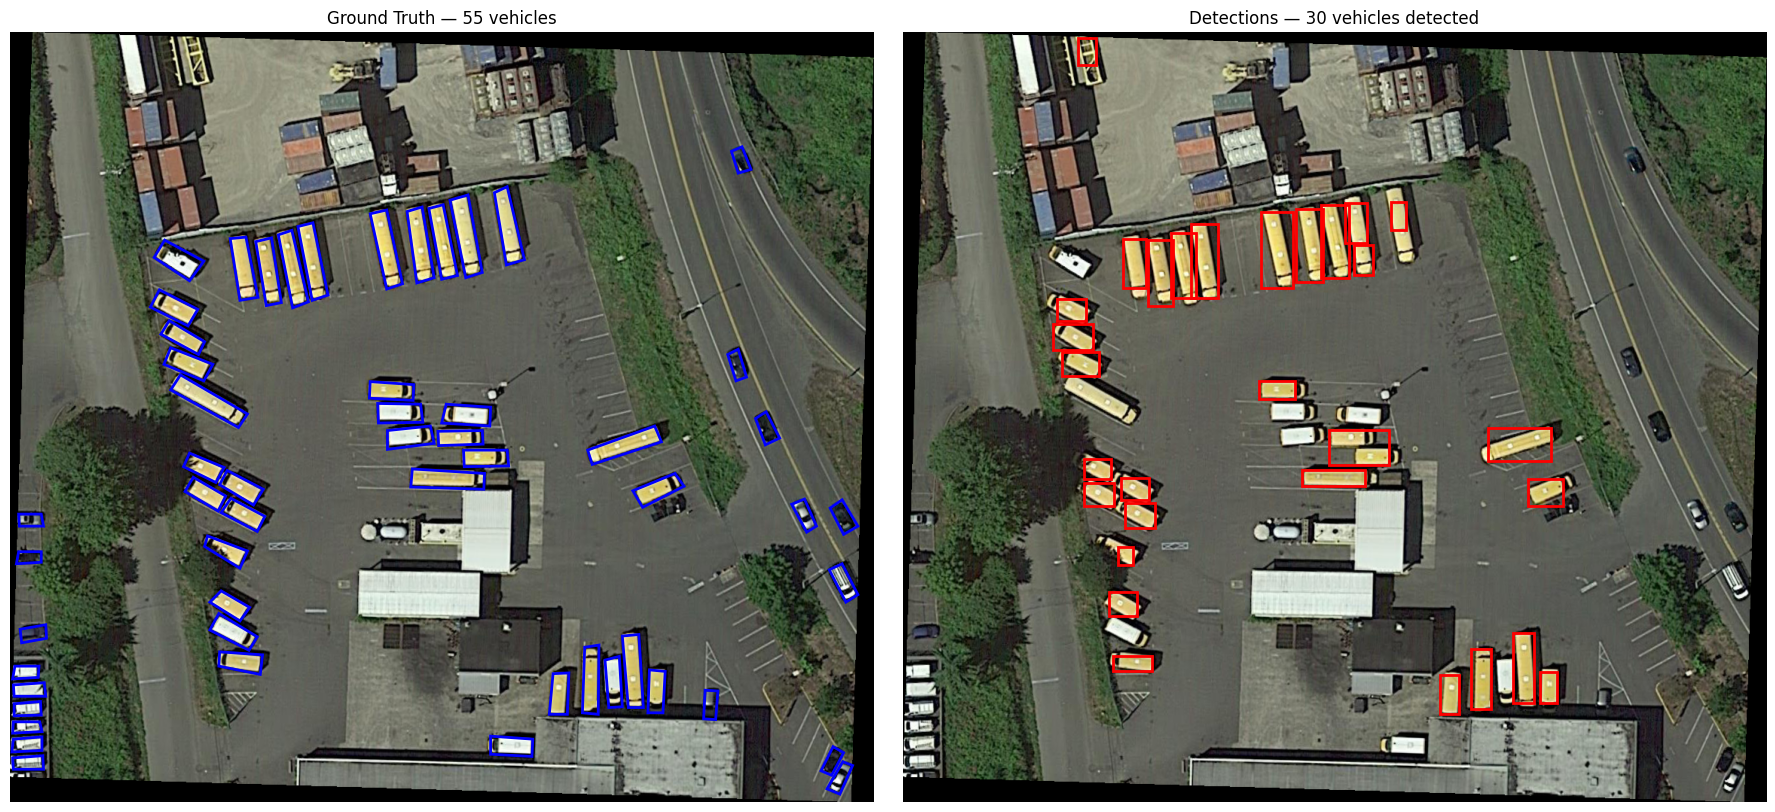

Detection result saved.


In [ ]:
# Step 5 - Finding connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_clean)

# Step 6 - Filter by size (removal too small and too large blobs)
min_area = 300
max_area = 15000

detected_boxes = []
for i in range(1, num_labels):  # skip background (label 0)
    area = stats[i, cv2.CC_STAT_AREA]
    if min_area < area < max_area:
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        detected_boxes.append((x, y, w, h))

print(f"Total detections after size filtering: {len(detected_boxes)}")

# Step 7 - Visualization of detections vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Ground truth
axes[0].imshow(img_rgb)
for ann in annotations:
    coords = ann['coords']
    pts = np.array([[coords[0], coords[1]],
                    [coords[2], coords[3]],
                    [coords[4], coords[5]],
                    [coords[6], coords[7]]])
    polygon = Polygon(pts, closed=True, edgecolor='blue', facecolor='none', linewidth=2)
    axes[0].add_patch(polygon)
axes[0].set_title(f'Ground Truth — {len(annotations)} vehicles')
axes[0].axis('off')

# Detections
axes[1].imshow(img_rgb)
for (x, y, w, h) in detected_boxes:
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)
axes[1].set_title(f'Detections — {len(detected_boxes)} vehicles detected')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/Dataset/detection_result.png', dpi=150)
plt.show()
print("Detection result saved.")

In [ ]:
# Step 8 - Calculation of Precision and Recall
# We compare against large-vehicle ground truth only
# since our detector only targets yellow (large) vehicles

large_vehicle_gt = [ann for ann in annotations if ann['category'] == 'large-vehicle']
print(f"Ground truth large vehicles: {len(large_vehicle_gt)}")
print(f"Total detections: {len(detected_boxes)}")

# Simple IoU-based matching
def get_gt_bbox(ann):
    coords = ann['coords']
    x_coords = [coords[0], coords[2], coords[4], coords[6]]
    y_coords = [coords[1], coords[3], coords[5], coords[7]]
    x1, y1 = min(x_coords), min(y_coords)
    x2, y2 = max(x_coords), max(y_coords)
    return (x1, y1, x2-x1, y2-y1)

def compute_iou(det, gt):
    dx, dy, dw, dh = det
    gx, gy, gw, gh = gt

    ix1 = max(dx, gx)
    iy1 = max(dy, gy)
    ix2 = min(dx+dw, gx+gw)
    iy2 = min(dy+dh, gy+gh)

    if ix2 < ix1 or iy2 < iy1:
        return 0.0

    intersection = (ix2-ix1) * (iy2-iy1)
    union = dw*dh + gw*gh - intersection
    return intersection / union

# Match detections to ground truth
iou_threshold = 0.3
gt_boxes = [get_gt_bbox(ann) for ann in large_vehicle_gt]
matched_gt = set()
true_positives = 0

for det in detected_boxes:
    best_iou = 0
    best_gt_idx = -1
    for j, gt in enumerate(gt_boxes):
        if j in matched_gt:
            continue
        iou = compute_iou(det, gt)
        if iou > best_iou:
            best_iou = iou
            best_gt_idx = j
    if best_iou >= iou_threshold and best_gt_idx != -1:
        true_positives += 1
        matched_gt.add(best_gt_idx)

false_positives = len(detected_boxes) - true_positives
false_negatives = len(gt_boxes) - true_positives

precision = true_positives / len(detected_boxes) if detected_boxes else 0
recall = true_positives / len(gt_boxes) if gt_boxes else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nTrue Positives: {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {round(precision, 3)}")
print(f"Recall: {round(recall, 3)}")
print(f"F1 Score: {round(f1, 3)}")

Ground truth large vehicles: 40
Total detections: 30

True Positives: 26
False Positives: 4
False Negatives: 14
Precision: 0.867
Recall: 0.65
F1 Score: 0.743


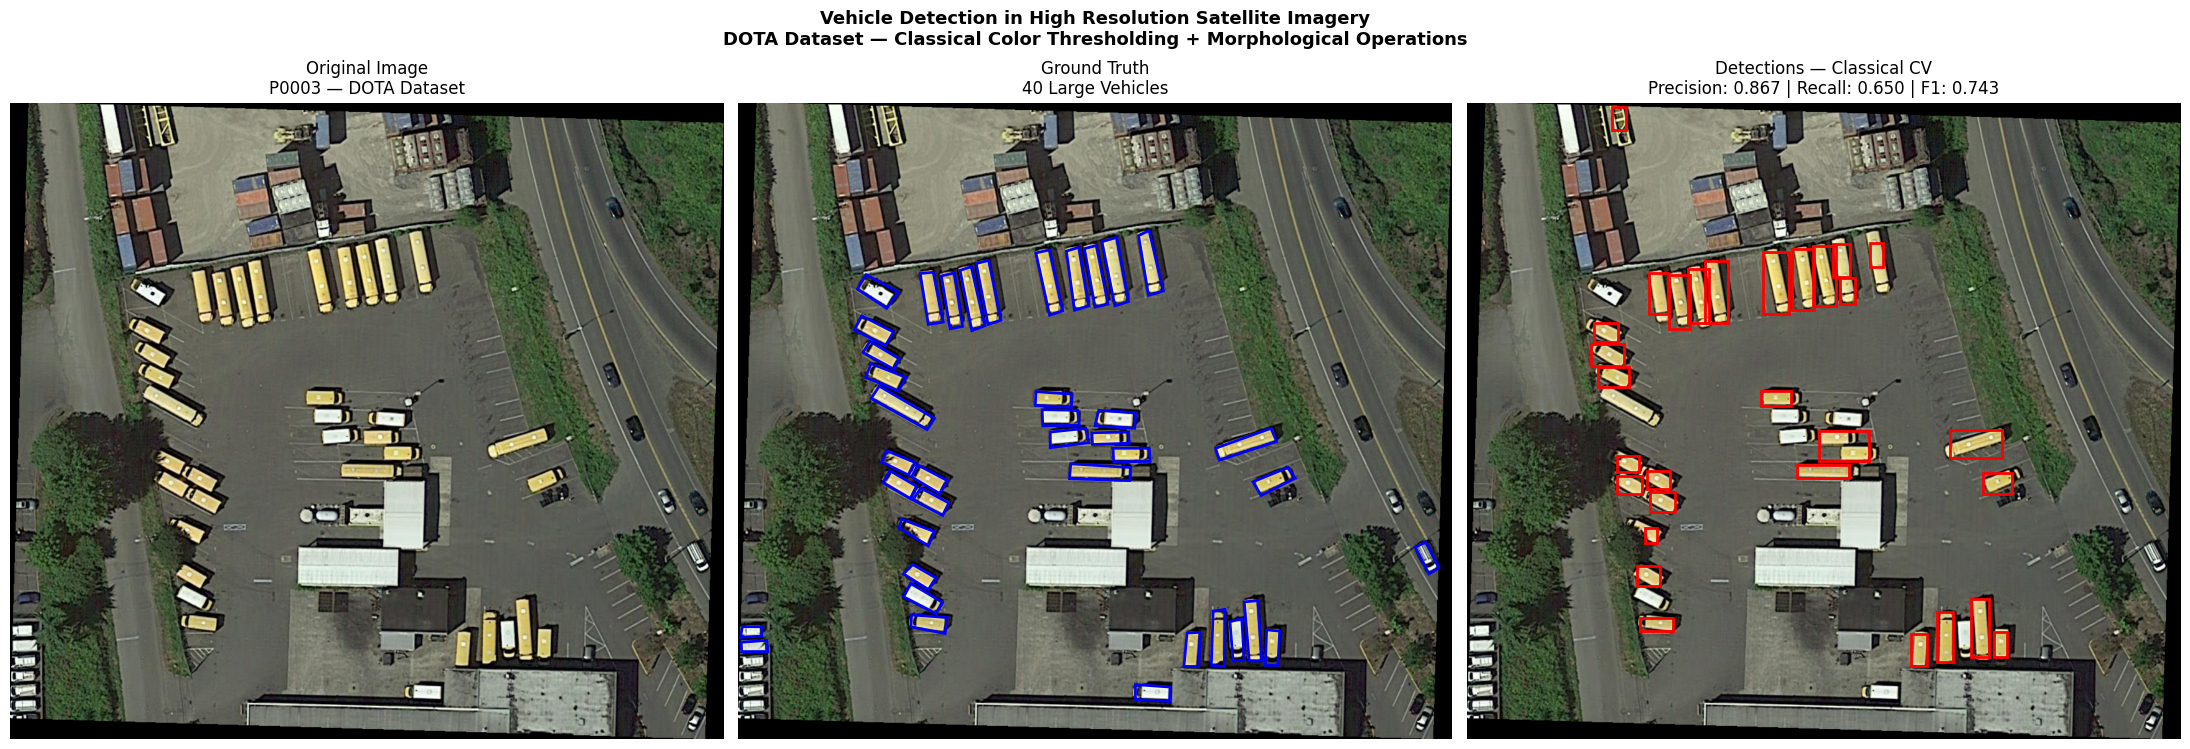

Final result saved.


In [ ]:
# Step 9 - Final summary visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Original
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image\nP0003 — DOTA Dataset', fontsize=12)
axes[0].axis('off')

# Ground Truth
axes[1].imshow(img_rgb)
for ann in large_vehicle_gt:
    coords = ann['coords']
    pts = np.array([[coords[0], coords[1]],
                    [coords[2], coords[3]],
                    [coords[4], coords[5]],
                    [coords[6], coords[7]]])
    polygon = Polygon(pts, closed=True, edgecolor='blue', facecolor='none', linewidth=2)
    axes[1].add_patch(polygon)
axes[1].set_title(f'Ground Truth\n{len(large_vehicle_gt)} Large Vehicles', fontsize=12)
axes[1].axis('off')

# Detections
axes[2].imshow(img_rgb)
for (x, y, w, h) in detected_boxes:
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[2].add_patch(rect)
axes[2].set_title(f'Detections — Classical CV\nPrecision: 0.867 | Recall: 0.650 | F1: 0.743', fontsize=12)
axes[2].axis('off')

plt.suptitle('Vehicle Detection in High Resolution Satellite Imagery\nDOTA Dataset — Classical Color Thresholding + Morphological Operations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/Dataset/final_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final result saved.")